In [1]:
import scanpy as sc
import squidpy as sq
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import anndata as ad
import dill
import h5py
import os
from typing import Dict, List, Tuple, Optional, Union
import json
import gc

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  retur

In [2]:
BASE_PATH = Path('/auto/brno2/home/luciakostialova/Master_thesis/10xVisium/BRCA1/')
data = sq.read.visium(BASE_PATH, counts_file='Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5')
library_id='Visium_Human_Breast_Cancer'
data

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4898 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

# Explore the gene expression data distribution, how does preprocessing change the data?

## Plots

THIS IS UNPROCESSED DATA !!!


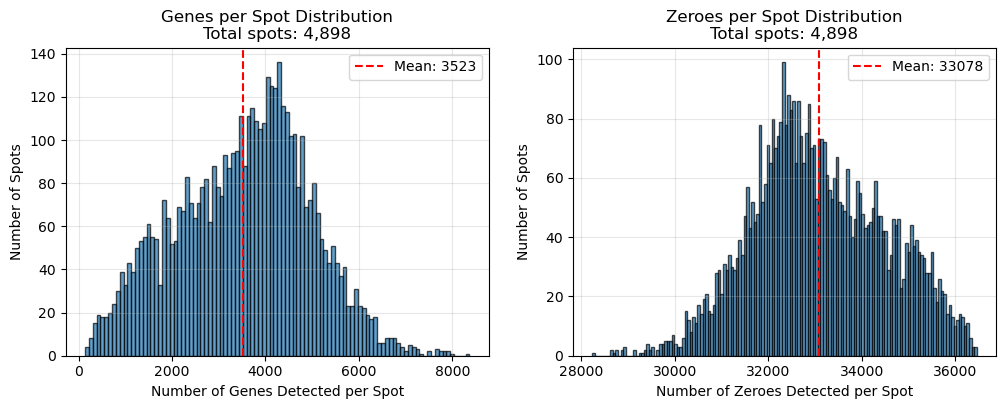

In [3]:
# Convert to dense array once (saves memory)
dense_data = data.X.toarray()

# Get basic information
genes = data.X.shape[1]
spots = data.X.shape[0]

print(f'THIS IS UNPROCESSED DATA !!!')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PLOT 1: Genes per spot
genes_per_spot = np.count_nonzero(dense_data, axis=1)  # count non-zero entries per spot, row-wise

axes[0].hist(genes_per_spot, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Genes Detected per Spot')
axes[0].set_ylabel('Number of Spots')
axes[0].set_title(f'Genes per Spot Distribution\nTotal spots: {spots:,}')
axes[0].axvline(genes_per_spot.mean(), color='red', linestyle='--', label=f'Mean: {genes_per_spot.mean():.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PLOT 2: Zeroes per spot
zero_values = genes-genes_per_spot

axes[1].hist(zero_values, bins=150, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Zeroes Detected per Spot')
axes[1].set_ylabel('Number of Spots')
axes[1].set_title(f'Zeroes per Spot Distribution\nTotal spots: {spots:,}')
axes[1].axvline(zero_values.mean(), color='red', linestyle='--', label=f'Mean: {zero_values.mean():.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

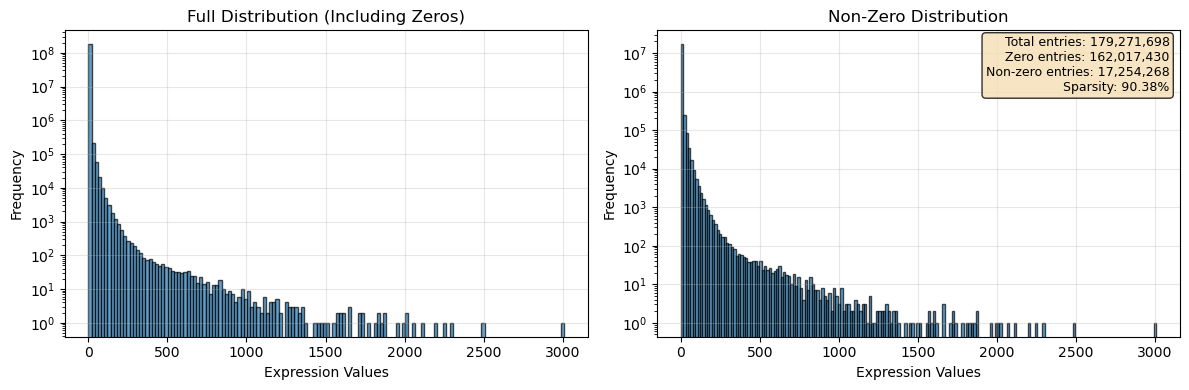

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dense_data = data.X.toarray()

# PLOT 1: WITH ZEROS
axes[0].hist(dense_data.flatten(), bins=150, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Expression Values')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Full Distribution (Including Zeros)')
axes[0].set_yscale('log')  # Log scale helps see distribution
axes[0].grid(True, alpha=0.3)

# PLOT 2: WITHOUT ZEROS
non_zero_data = dense_data[dense_data > 0]
zero_data = dense_data[dense_data==0]
axes[1].hist(non_zero_data, bins=200, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Expression Values')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Non-Zero Distribution')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Add text box with statistics
stats_text = f"Total entries: {spots*genes:,}\n"
stats_text += f"Zero entries: {len(zero_data):,}\n"
stats_text += f"Non-zero entries: {len(non_zero_data):,}\n"
stats_text += f"Sparsity: {len(zero_data)/(spots*genes):.2%}"
axes[1].text(0.98, 0.98, stats_text, transform=axes[1].transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Print additional statistics
print(f"Dataset shape: {spots} spots × {genes} genes")
print(f"Mean genes per spot: {genes_per_spot.mean():.0f} ± {genes_per_spot.std():.0f}")
print(f"Min genes detected per spot: {genes_per_spot.min()}")
print(f"Max genes detected per spot: {genes_per_spot.max()}")
print(f"\nNon-zero expression values:")
print(f"  Unique non-zero values: {len(non_zero_data):,}")
print(f"  Min non-zero value: {non_zero_data.min():.4f}")
print(f"  Max non-zero value: {non_zero_data.max():.4f}")

Dataset shape: 4898 spots × 36601 genes
Mean genes per spot: 3523 ± 1428
Min genes detected per spot: 140
Max genes detected per spot: 8367

Non-zero expression values:
  Unique non-zero values: 17,254,268
  Min non-zero value: 1.0000
  Max non-zero value: 3007.0000


## Preprocessing

In [43]:
# preprocessing from scanpy workflow
adata = data.copy()
adata.var_names_make_unique()
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)
adata

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4898 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

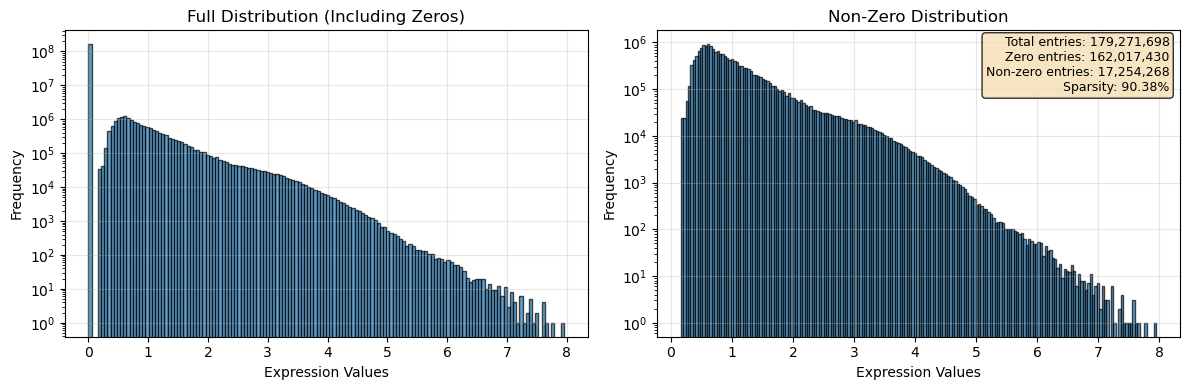

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

adense_data = adata.X.toarray()

# PLOT 1: WITH ZEROS
axes[0].hist(adense_data.flatten(), bins=150, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Expression Values')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Full Distribution (Including Zeros)')
axes[0].set_yscale('log')  # Log scale helps see distribution
axes[0].grid(True, alpha=0.3)

# PLOT 2: WITHOUT ZEROS
non_zero_data = adense_data[adense_data > 0]
zero_data = adense_data[adense_data == 0]

axes[1].hist(non_zero_data, bins=200, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Expression Values')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Non-Zero Distribution')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Add text box with statistics
stats_text = f"Total entries: {spots*genes:,}\n"
stats_text += f"Zero entries: {len(zero_data):,}\n"
stats_text += f"Non-zero entries: {len(non_zero_data):,}\n"
stats_text += f"Sparsity: {len(zero_data)/(spots*genes):.2%}"
axes[1].text(0.98, 0.98, stats_text, transform=axes[1].transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=9)

plt.tight_layout()
plt.show()

In [37]:
genes = adata.X.shape[1]
spots = adata.X.shape[0]

genes_per_spot = np.count_nonzero(adense_data, axis=1)

print(f"Dataset shape: {spots} spots × {genes} genes")
print(f"Mean genes per spot: {genes_per_spot.mean():.0f} ± {genes_per_spot.std():.0f}")
print(f"Min genes detected per spot: {genes_per_spot.min()}")
print(f"Max genes detected per spot: {genes_per_spot.max()}")
print(f"\nNon-zero expression values:")
print(f"  Unique non-zero values: {len(non_zero_data):,}")
print(f"  Min non-zero value: {non_zero_data.min():.4f}")
print(f"  Max non-zero value: {non_zero_data.max():.4f}")

Dataset shape: 4898 spots × 36601 genes
Mean genes per spot: 3523 ± 1428
Min genes detected per spot: 140
Max genes detected per spot: 8367

Non-zero expression values:
  Unique non-zero values: 17,254,268
  Min non-zero value: 0.1632
  Max non-zero value: 7.9469


In [40]:
adata.var_names_make_unique()
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [49]:
sc.pp.calculate_qc_metrics(
    adata, inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 4898 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'tsne'
    obsm: 'spatial', 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

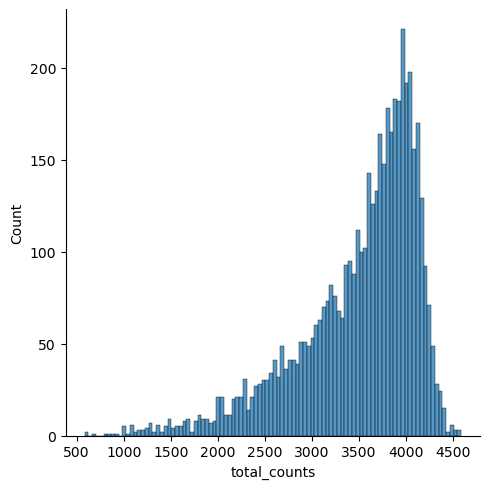

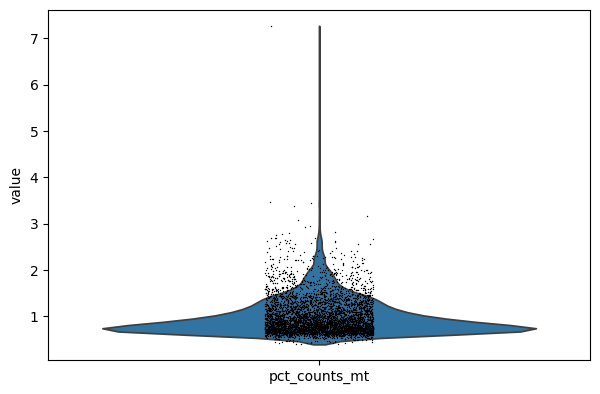

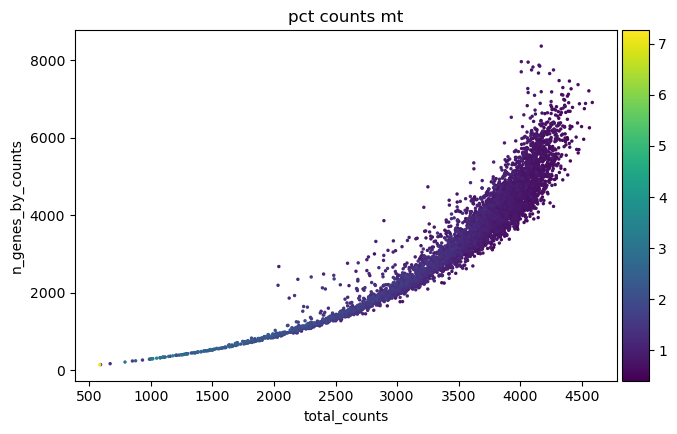

In [42]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

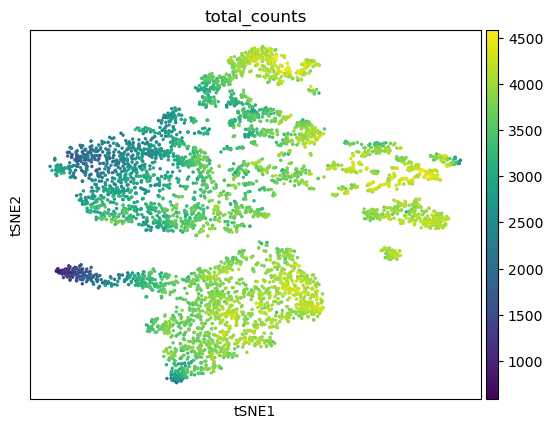

In [50]:
sc.tl.tsne(adata, use_rep="X_pca")
sc.pl.tsne(adata, color="total_counts")

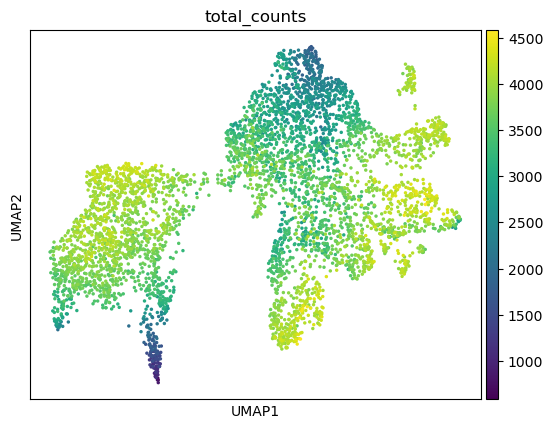

In [51]:
sc.pl.umap(adata, color="total_counts")

## QC & Preprocessing - 10XVisium

In [37]:
adata = data.copy()
adata.var_names_make_unique()

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [38]:
adata

AnnData object with n_obs × n_vars = 4898 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

The analysis begins by removing low-quality cell segmentation bins from the datasets. In this example, this is done by visualizing the total UMI distribution to estimate a suitable cutoff for empty or sparsely populated bins. Even though mitochondrial content is calculated, it is not used as a filtering criterion, as high levels of mitochondrial genes can be biologically relevant in spatial data

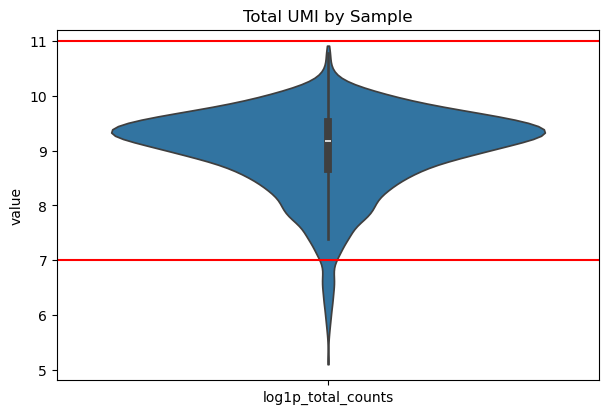

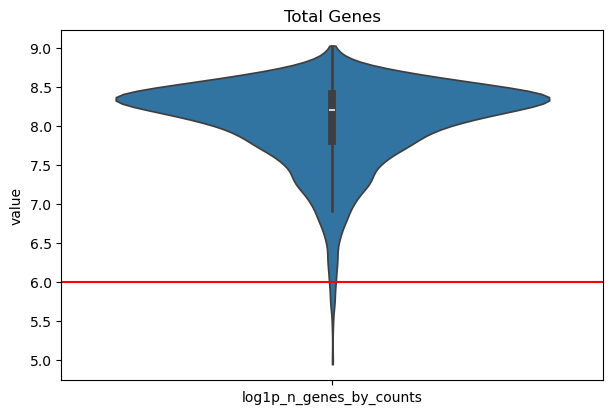

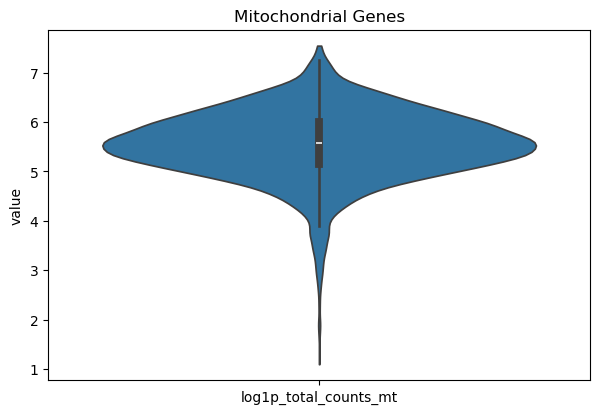

In [39]:
# Add mitochondrial gene calculation for QC
adata.var["mt"] = adata.var_names.str.startswith(("MT-", "mt-"))
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None)

# Visualization for QC
sc.pl.violin(adata=adata, keys=["log1p_total_counts"], stripplot=False, inner="box",show=False,)
plt.title("Total UMI by Sample")
plt.axhline(y=7, color='r', linestyle='-')
plt.axhline(y=11, color='r', linestyle='-')
plt.title("Total UMI by Sample")
plt.show()

sc.pl.violin(adata=adata, keys=["log1p_n_genes_by_counts"], stripplot=False, inner="box",show=False)
plt.title("Total Genes")
plt.axhline(y=6, color='r', linestyle='-')
plt.show()

sc.pl.violin(adata=adata, keys=["log1p_total_counts_mt"], stripplot=False, inner="box",show=False)
plt.title("Mitochondrial Genes")
plt.show()

plt.close('all')

Based on the log1p total UMI violin plot, cell segmentation bins with fewer than 53 counts (corresponding to a log1p value of 4) and more than 2,979 counts (corresponding to a log1p value of 8) are removed from the datasets using Scanpy’s filter_cells function. Additionally, genes present in fewer than 50 cell segmentation bins are excluded from the analysis using Scanpy’s filter_genes function. It is important to note that both the count cutoffs and the number of bins a gene must be present in will vary between experiments and should be determined empirically.

In this example, we filtered all the datasets using the same criteria. However, with a different set of datasets, the samples may need to be filtered using sample-specific criteria

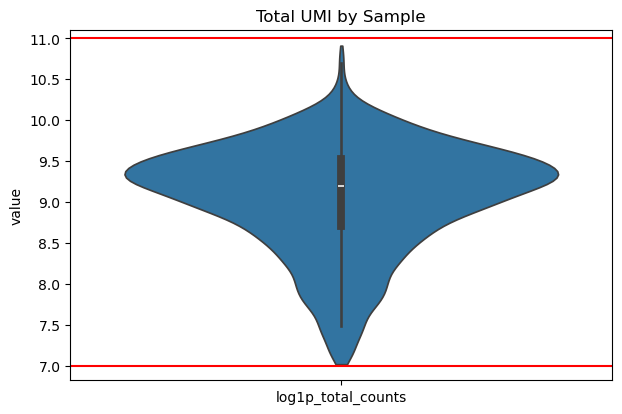

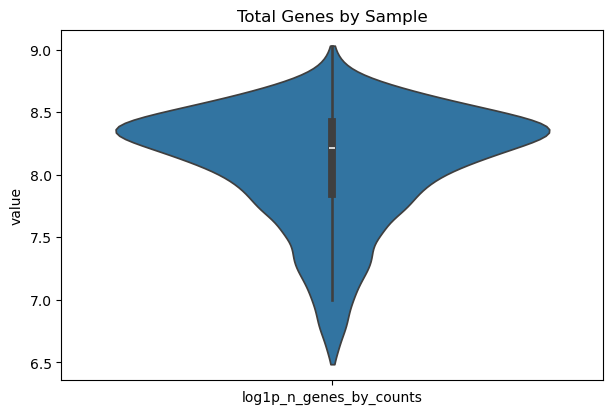

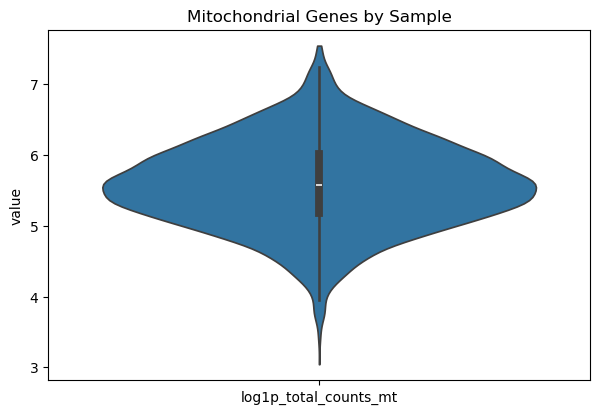

13994

In [41]:
# Estimating the cut off
min_counts = np.expm1(7).astype("int")
max_counts = np.expm1(11).astype("int")
min_cells = np.expm1(6).astype("int")

# Filtering genes and cells
sc.pp.filter_genes(adata, min_cells=min_cells)
sc.pp.filter_cells(adata, min_counts=min_counts)
sc.pp.filter_cells(adata, max_counts=max_counts)

# Visualization for QC
sc.pl.violin(adata=adata, keys=["log1p_total_counts"], stripplot=False, inner="box",show=False,)
plt.title("Total UMI by Sample")
plt.axhline(y=7, color='r', linestyle='-')
plt.axhline(y=11, color='r', linestyle='-')
plt.title("Total UMI by Sample")
plt.show()

sc.pl.violin(adata=adata, keys=["log1p_n_genes_by_counts"], stripplot=False, inner="box",show=False)
plt.title("Total Genes by Sample")
plt.show()

sc.pl.violin(adata=adata, keys=["log1p_total_counts_mt"], stripplot=False, inner="box",show=False)
plt.title("Mitochondrial Genes by Sample")
plt.show()

plt.close('all')

# storing filtered counts
adata.layers["filtered_counts"] = adata.X.copy()

del max_counts, min_counts
gc.collect()

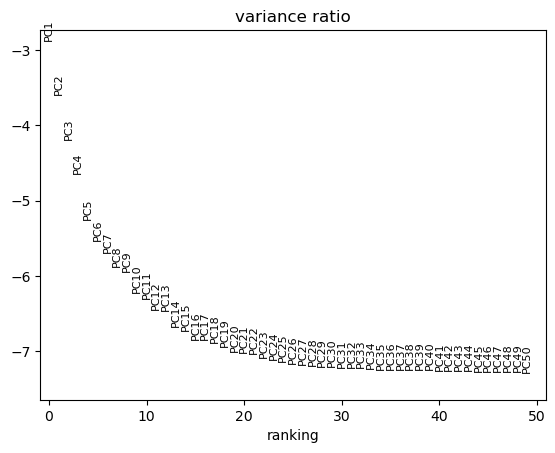

CPU times: user 8.5 s, sys: 7.95 ms, total: 8.51 s
Wall time: 8.92 s


In [42]:
%%time

sc.pp.normalize_total(adata, target_sum = None)
sc.pp.log1p(adata)
sc.tl.pca(adata)

# adata.write("preprocessed_adata.h5ad")

# Elbow plot
sc.pl.pca_variance_ratio(adata, log=True,n_pcs=50)

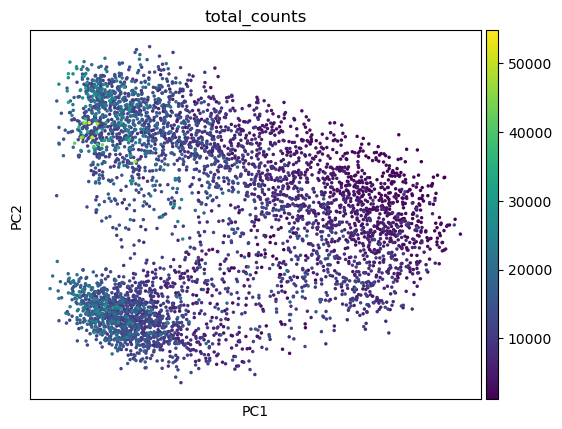

In [75]:
sc.pl.pca_scatter(adata, color="total_counts")

Now that we have standardized the data and performed a PCA, we will cluster and visualize the results. Scanpy's neighbors function generates a neighbor distance matrix and a neighborhood graph, which is used by Scanpy's leiden function to cluster the data. Finally, Scanpy’s umap function is used to visualize the results.

In [48]:
# probably best not to use PCA - doesn't make sense on sparse data

In [59]:
adata.uns['neighbors']['distances_key']

'distances'

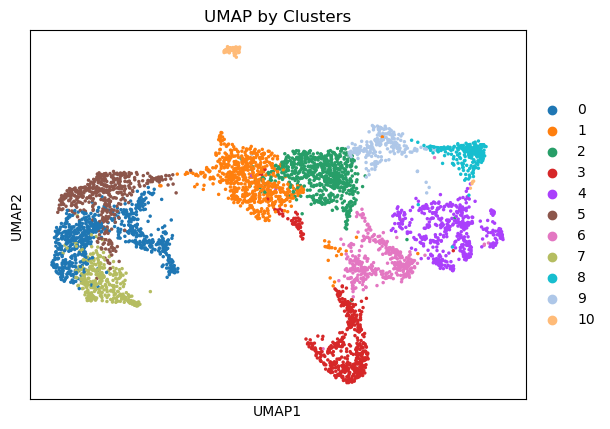

CPU times: user 7.42 s, sys: 48.6 ms, total: 7.47 s
Wall time: 7.5 s


4334

In [49]:
%%time

# neighborhood and clustering resolution
RES = 0.5 # clustering resolution
NEIGHBORS = 20  # number of neighbors

MIN_DIST=0.5 #default 0.5
SPREAD=2 #default 1

sc.pp.neighbors(adata, n_neighbors=NEIGHBORS, metric="cosine")  # use_rep="X_pca",
sc.tl.leiden(adata, flavor="igraph", key_added="clusters", resolution=RES,random_state=0)

# To ensure that the results are reproducible we are going to reorder the clusters by size.
adata.obs['orig_clusters'] = adata.obs['clusters']

clusters = adata.obs['clusters'].astype(int)

# Count cells per cluster
cluster_sizes = clusters.value_counts().sort_values(ascending=False)

# Create mapping: old cluster ID → new ordered ID
cluster_order = {old: new for new, old in enumerate(cluster_sizes.index)}

# Relabel clusters in adata
adata.obs['clusters'] = clusters.map(cluster_order).astype(str)

# Set random_state for reproducible UMAP
sc.tl.umap(adata,min_dist=MIN_DIST, spread=SPREAD, random_state=0)

# Plot UMAP
sc.pl.umap(adata, color=["clusters"], title="UMAP by Clusters")

del RES, NEIGHBORS, MIN_DIST, SPREAD
gc.collect()

To annotate the clusters, we can utilize canonical marker genes, or determine cluster-specific marker genes and then analyze the upregulated genes. We begin by using Scanpy's dotplot function to visualize cell type markers in the samples, grouped by their respective clusters within the AnnData object. A third option is to integrate an annotated single-cell RNA-seq dataset to label the clusters, which is beyond the scope of this guide. In this analysis, we are considering only a subset of cells that can be present. To identify other cell types such as T cells, we will likely need a finer clustering resolution.

In [66]:
adata.var

,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
SAMD11,ENSG00000187634,Gene Expression,GRCh38,False,950,0.252348,0.225020,80.604328,1236.0,7.120444,949
NOC2L,ENSG00000188976,Gene Expression,GRCh38,False,2039,0.601878,0.471177,58.370764,2948.0,7.989222,2036
KLHL17,ENSG00000187961,Gene Expression,GRCh38,False,599,0.135361,0.126951,87.770519,663.0,6.498282,598
HES4,ENSG00000188290,Gene Expression,GRCh38,False,3236,1.524091,0.925881,33.932217,7465.0,8.918115,3230
ISG15,ENSG00000187608,Gene Expression,GRCh38,False,4842,15.167211,2.782985,1.143324,74289.0,11.215732,4783
...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,ENSG00000212907,Gene Expression,GRCh38,True,2482,0.813802,0.595425,49.326256,3986.0,8.290794,2477
MT-ND4,ENSG00000198886,Gene Expression,GRCh38,True,4894,32.507554,3.511771,0.081666,159222.0,11.978061,4797
MT-ND5,ENSG00000198786,Gene Expression,GRCh38,True,4056,2.631482,1.289641,17.190690,12889.0,9.464207,4025
MT-CYB,ENSG00000198727,Gene Expression,GRCh38,True,4889,28.324418,3.378421,0.183748,138733.0,11.840314,4796


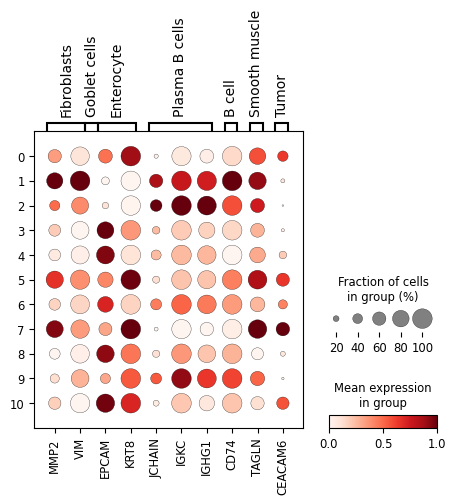

In [74]:
# cannonical markers for annotation
marker_genes = {
    "Fibroblasts": ["MMP2", 'VIM'],
    "Goblet cells": [],
    "Enterocyte":["EPCAM","KRT8",],
    "Plasma B cells":['JCHAIN','IGKC','IGHG1'],
    "B cell":['CD74'],
    "Smooth muscle":['TAGLN'],
    "Tumor":["CEACAM6"]
}

# Plot dotplot for initial cluster assessment

sc.pl.dotplot(adata, var_names = marker_genes, groupby="clusters", standard_scale="var")

In [78]:
# Method 1: Standard (with PCA)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=20, use_rep="X_pca")
sc.tl.leiden(adata, resolution=0.5)
clusters_pca = adata.obs['leiden'].copy()

# Method 2: Direct (without PCA)
sc.pp.neighbors(adata, n_neighbors=20, use_rep="X")
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_direct")
clusters_direct = adata.obs['leiden_direct'].copy()

# Compare clustering consistency
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(clusters_pca, clusters_direct)
print(f"ARI between PCA-based and direct clustering: {ari:.3f}")

ARI between PCA-based and direct clustering: 0.326


In [ ]:
import scanpy as sc
from sklearn.metrics import adjusted_rand_score

# Method A: Correct (PCA for analysis, UMAP for viz)
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.leiden(adata, key_added="clusters_pca")
sc.tl.umap(adata)
clusters_pca = adata.obs["clusters_pca"].copy()

# Method B: Problematic (UMAP for both)
sc.tl.umap(adata, n_components=30)  # High-dim UMAP
sc.pp.neighbors(adata, use_rep="X_umap")
sc.tl.leiden(adata, key_added="clusters_umap")
sc.tl.umap(adata, n_components=2)  # 2D for viz
clusters_umap = adata.obs["clusters_umap"].copy()

# Compare - they might be similar but UMAP-based is circular
ari = adjusted_rand_score(clusters_pca, clusters_umap)
print(f"Clustering similarity: {ari:.3f}")

## Clustering

### Gene expression distances and clustering

In [61]:
adata.obsm['X_pca']

array([[ 3.7512493 , -3.8411517 , -1.0971265 , ...,  0.15468481,
        -0.4637329 , -0.5266336 ],
       [ 4.0347705 , -3.560998  , -2.6574013 , ...,  0.11245668,
         0.20950212,  0.19559442],
       [-3.2341697 , -3.207758  , -2.5226438 , ...,  0.4282952 ,
         0.5841108 ,  0.2999665 ],
       ...,
       [-6.2489862 ,  4.820709  ,  1.2045648 , ...,  0.06101331,
         0.5407897 ,  0.23828992],
       [-3.1930847 ,  5.7321987 ,  3.5591788 , ..., -0.88159424,
         1.1335549 , -0.22220607],
       [ 4.660179  , -2.8920302 , -0.6708047 , ..., -1.1435965 ,
         0.66114897,  0.40076128]], shape=(4744, 50), dtype=float32)

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


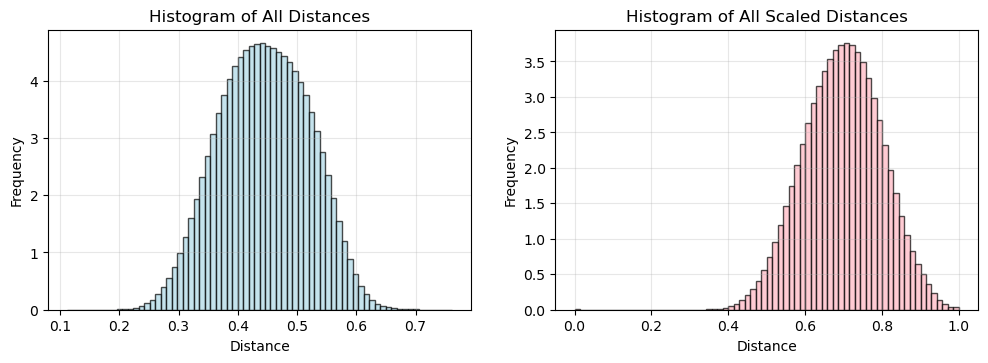

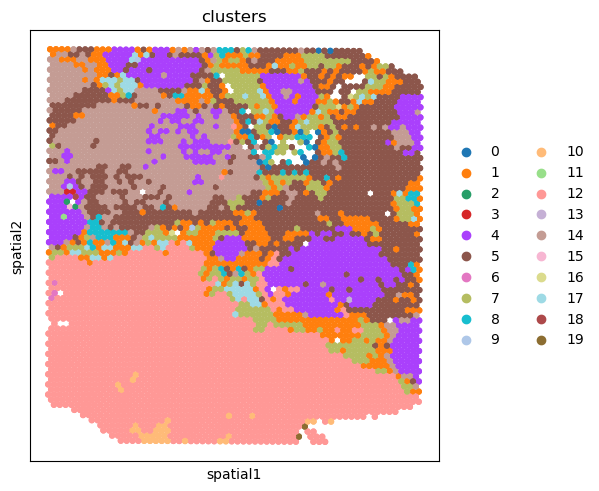

In [68]:
clustering(adata, metric='correlation', linkage='complete')

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


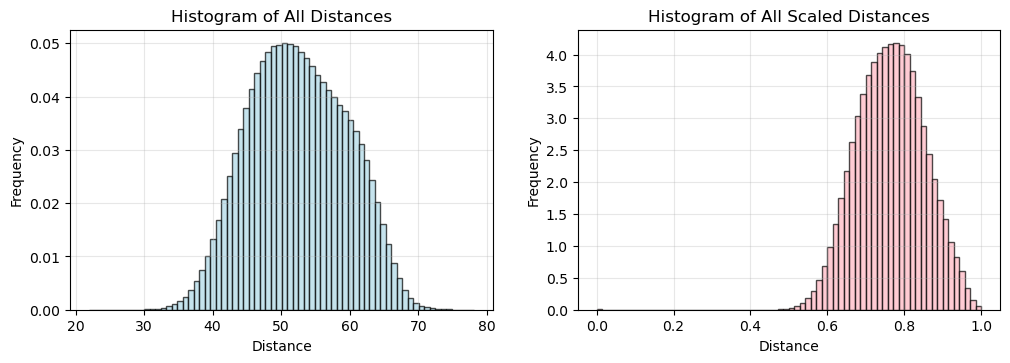

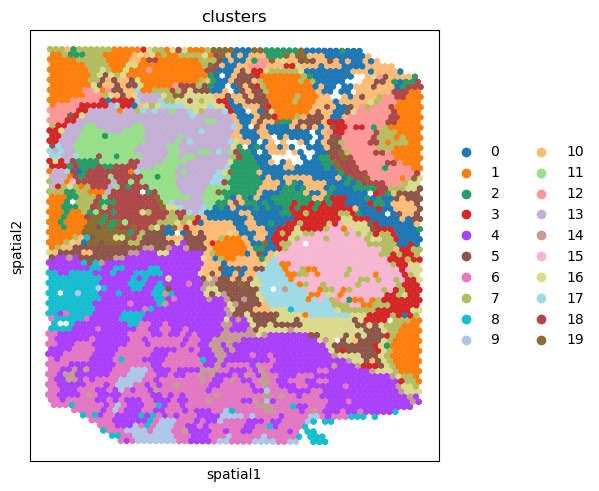

In [69]:
clustering(adata, metric='euclidean', linkage='ward')

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


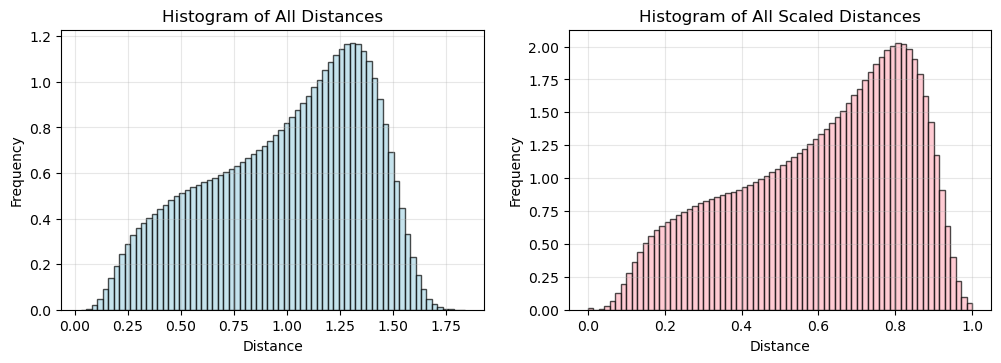

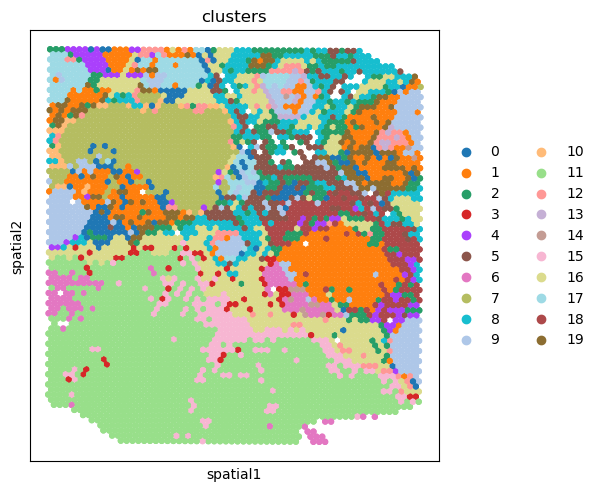

In [67]:
clustering(adata, metric='correlation', linkage='complete', x_pca=True)

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


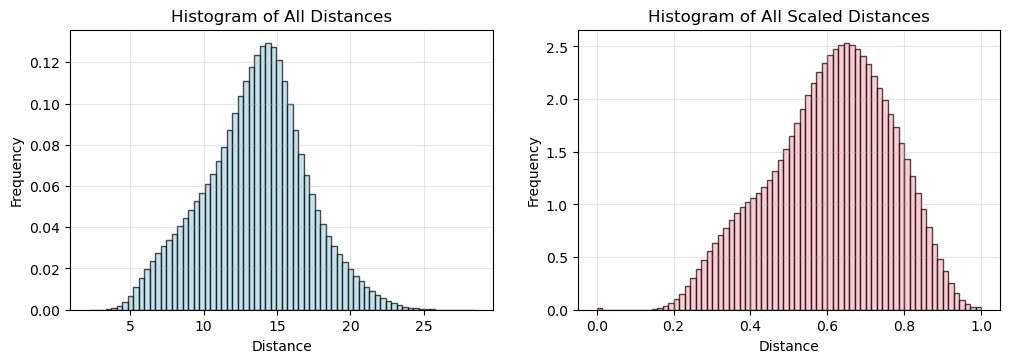

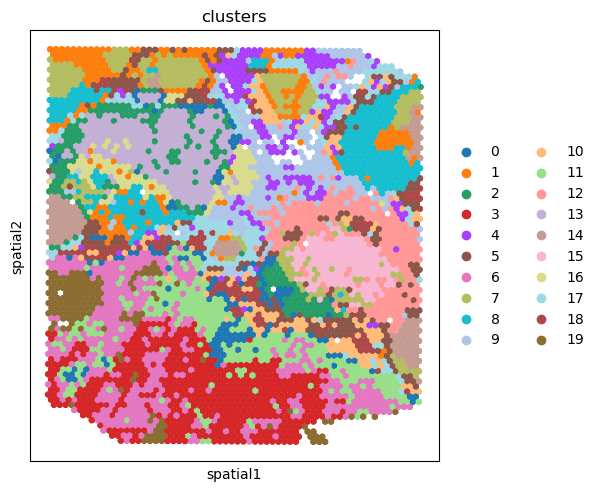

In [70]:
clustering(adata, metric='euclidean', linkage='ward', x_pca=True)

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


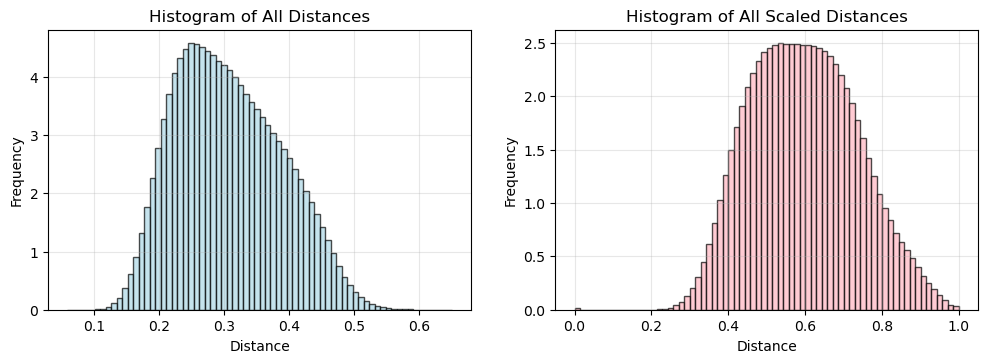

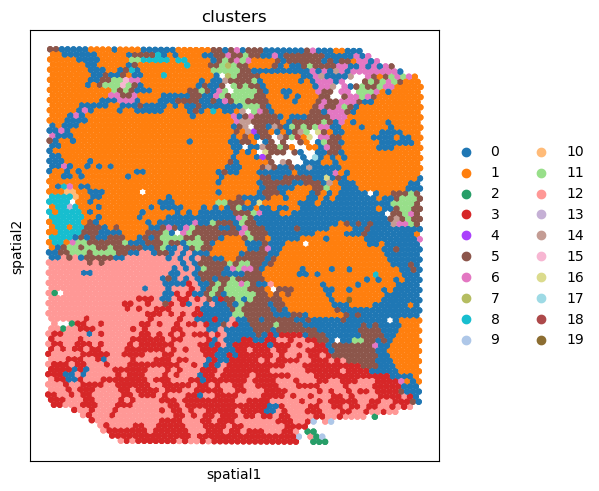

In [71]:
clustering(adata, metric='cosine', linkage='complete')

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


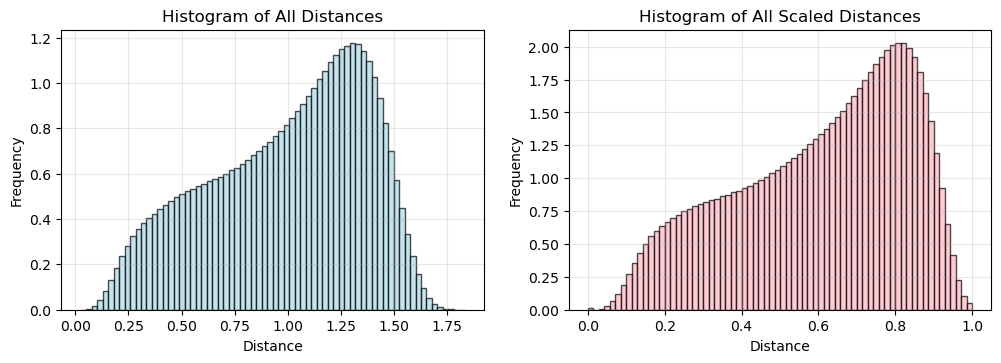

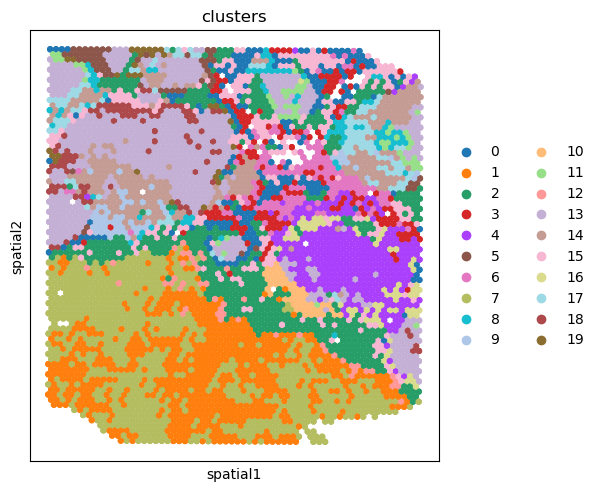

In [72]:
clustering(adata, metric='cosine', linkage='complete', x_pca=True)

In [80]:
adata

AnnData object with n_obs × n_vars = 4744 × 6311
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg', 'pca', 'clusters_colors', 'rank_genes_groups'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    layers: 'filtered_counts'

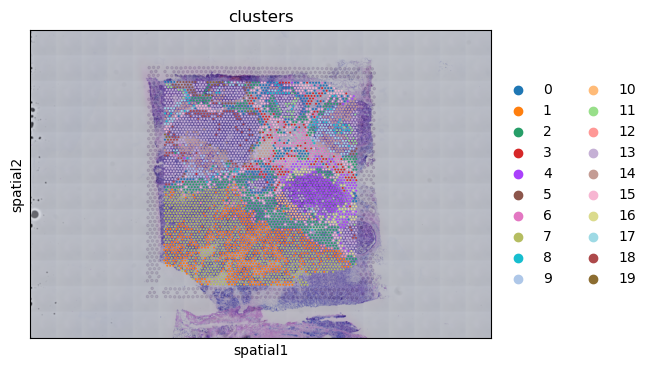

In [78]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(adata.obsm['X_pca'][:,:30], 
                            adata.obs['clusters'])

# 2. Spatial coherence (clusters should be spatially contiguous)
sq.pl.spatial_scatter(adata, color='clusters')

# 3. Marker gene expression by cluster
sc.tl.rank_genes_groups(adata, 'clusters', method='wilcoxon')

In [79]:
sil_score

0.07311377674341202